# Bayesian workflow: blood pressure and age

33 North American women (Sick & Dürr, *Probabilistic Deep Learning*, ch. 1).
We know two numbers per woman: **age** and **systolic blood pressure**.

We will not look at the blood pressures until step 3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

age = np.array([22, 41, 52, 23, 41, 54, 24, 46, 56, 27, 47, 57, 28, 48, 58, 9, 49, 59, 30, 49, 63,
                32, 50, 67, 33, 51, 71, 35, 51, 77, 40, 51, 81])
sbp = np.array([131, 139, 128, 128, 171, 105, 116, 137, 145, 106, 111, 141, 114, 115, 153, 123, 133,
                157, 117, 128, 155, 122, 183, 176, 99, 130, 172, 121, 133, 178, 147, 144, 217])  # <- do not look yet
xg = np.linspace(0, 90, 50)   # ages, for drawing lines

print(len(age), "women, ages", age.min(), "to", age.max())

33 women, ages 9 to 81


## 1. Write down how the data could have come about

Four lines of numpy. Every number is a belief, written down *before* looking at the data.

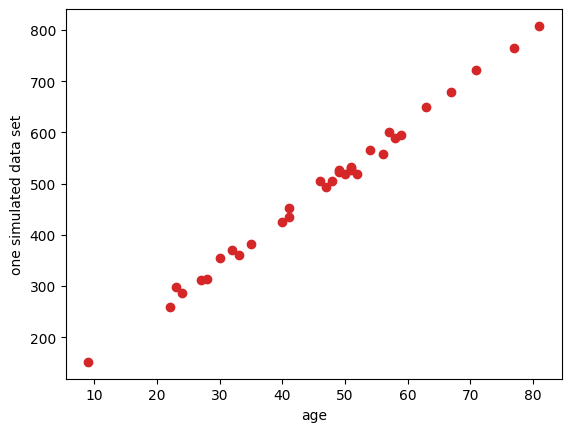

In [2]:
a     = np.random.normal(1, 5)          # SBP rises with age — how fast? not sure
b     = np.random.normal(100, 50)       # a newborn already has some blood pressure
sigma = abs(np.random.normal(0, 20))    # there is spread  (numpy has no half-normal)

sbp_sim = np.random.normal(b + a*age, sigma)

plt.scatter(age, sbp_sim, color="C3")
plt.xlabel("age"); plt.ylabel("one simulated data set");

## 2. Prior predictive: run the story 200 times

Does the world this story produces look like a world we believe in?
**Edit the priors and re-run until it does.**

simulated patients: 1–99% = -526 … 837 mmHg
below zero: 26.1%


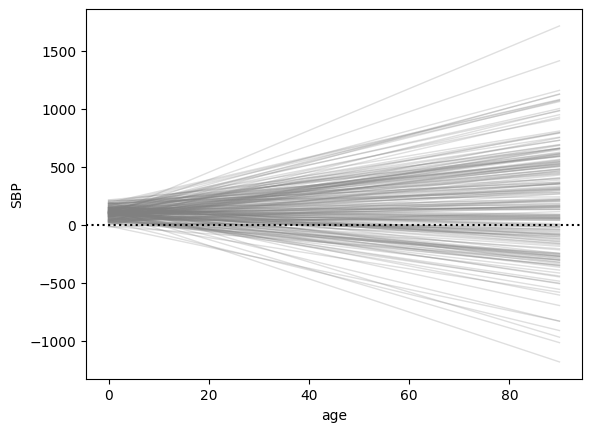

In [3]:
sims = []
for i in range(200):
    a     = np.random.normal(1, 5)
    b     = np.random.normal(100, 50)
    sigma = abs(np.random.normal(0, 20))
    sims.append(np.random.normal(b + a*age, sigma))
    plt.plot(xg, b + a*xg, color="gray", alpha=.25, lw=1)
sims = np.array(sims)

plt.axhline(0, ls=":", color="k"); plt.xlabel("age"); plt.ylabel("SBP")
print(f"simulated patients: 1–99% = {np.percentile(sims, 1):.0f} … {np.percentile(sims, 99):.0f} mmHg")
print(f"below zero: {(sims < 0).mean():.1%}")

Negative blood pressure for a quarter of the patients. The priors *looked* harmless.

Tighter: `a ~ N(1, 0.4)`, `b ~ N(90, 15)` — go back up, change the numbers, re-run.

## 3. Now look at the data

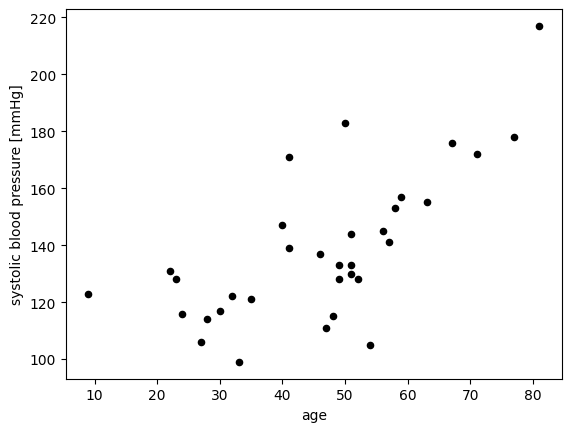

In [4]:
plt.scatter(age, sbp, color="k", s=20)
plt.xlabel("age"); plt.ylabel("systolic blood pressure [mmHg]");

## 4. Run the story backwards

numpy only runs forward: it forgets which distribution a number came from, and it can *draw*
from a distribution but not *evaluate* it. To go backwards we need a language that remembers.

The same four lines:

In [5]:
import numpyro, numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from jax import random

def model(age, sbp=None):
    a     = numpyro.sample("a",     dist.Normal(1, 0.4))
    b     = numpyro.sample("b",     dist.Normal(90, 15))
    sigma = numpyro.sample("sigma", dist.HalfNormal(20))
    numpyro.sample("sbp", dist.Normal(b + a*age, sigma), obs=sbp)

**Forward** — no data passed, so `sbp=None`. Exactly the numpy loop:

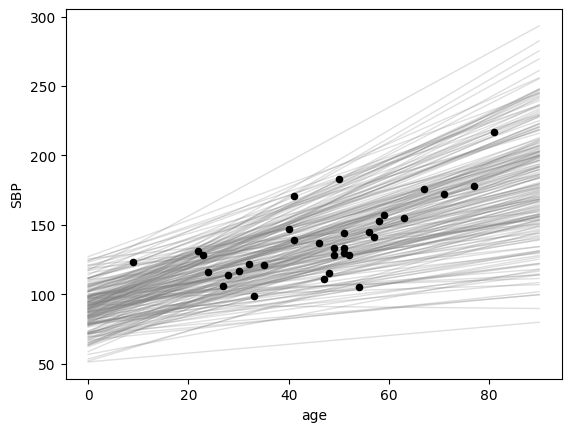

In [6]:
prior = Predictive(model, num_samples=200)(random.PRNGKey(0), age)

for a_, b_ in zip(prior["a"], prior["b"]):
    plt.plot(xg, b_ + a_*xg, color="gray", alpha=.25, lw=1)
plt.scatter(age, sbp, color="k", s=20, zorder=3)
plt.xlabel("age"); plt.ylabel("SBP");

**Backward** — pass the data:

In [7]:
mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc.run(random.PRNGKey(2), age, sbp=sbp)
post = mcmc.get_samples()

a_post = np.array(post["a"])
print(f"slope a:  mean {a_post.mean():.2f}   95% credible interval "
      f"[{np.percentile(a_post, 2.5):.2f}, {np.percentile(a_post, 97.5):.2f}]  mmHg per year")
print(f"P(a > 0 | data) = {(a_post > 0).mean():.4f}")

slope a:  mean 1.06   95% credible interval [0.74, 1.38]  mmHg per year
P(a > 0 | data) = 1.0000


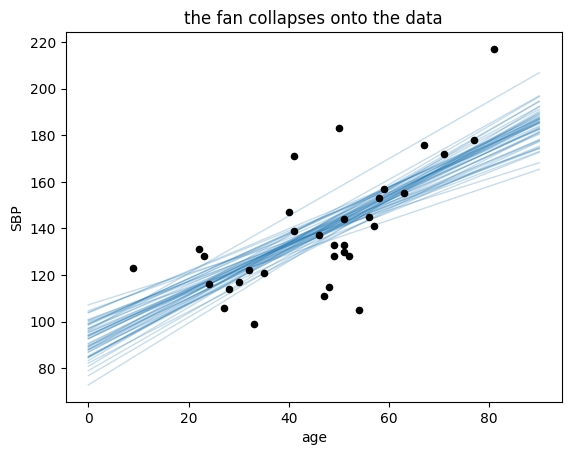

In [8]:
for a_, b_ in zip(post["a"][::40], post["b"][::40]):
    plt.plot(xg, b_ + a_*xg, color="C0", alpha=.25, lw=1)
plt.scatter(age, sbp, color="k", s=20, zorder=3)
plt.xlabel("age"); plt.ylabel("SBP"); plt.title("the fan collapses onto the data");

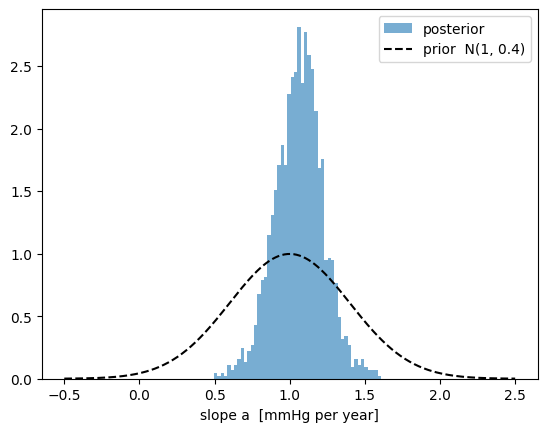

In [9]:
xs = np.linspace(-0.5, 2.5, 300)
plt.hist(a_post, bins=50, density=True, alpha=.6, label="posterior")
plt.plot(xs, np.exp(-0.5*((xs - 1)/0.4)**2) / (0.4*np.sqrt(2*np.pi)), "k--", label="prior  N(1, 0.4)")
plt.xlabel("slope a  [mmHg per year]"); plt.legend();

## 5. The same problem, the classical way

In [10]:
import statsmodels.api as sm
fit = sm.OLS(sbp, sm.add_constant(age)).fit()
print(fit.summary(xname=["const", "age"], yname="sbp").tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         87.6714     10.076      8.701      0.000      67.120     108.223
age            1.1050      0.206      5.364      0.000       0.685       1.525
